In [1]:
import pandas as pd
import numpy as np
import warnings

import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, DBSCAN  
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from kneed import KneeLocator

warnings.filterwarnings('ignore')

In [2]:
"""Utility functions for SVD and LSA notebook""" # UTILS

def plot_singular_values(singular_values, thresh=None):
    """Bar chart of raw singular values."""
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(1, len(singular_values) + 1)
    bars = ax.bar(x, singular_values, color='steelblue', edgecolor='none', alpha=0.85)

    if thresh is not None:
        ax.axvline(thresh, linestyle='--', lw=2, color='tab:orange', label=f'Threshold SV: {thresh}')
        ax.legend(fontsize=11)

    # Annotate top 10
    for i in range(min(10, len(singular_values))):
        ax.text(x[i], singular_values[i] + singular_values[0]*0.01,
                f'{singular_values[i]:.2f}', ha='center', va='bottom', fontsize=8, color='navy')

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Singular Value Index', fontsize=12)
    ax.set_ylabel('Singular Value Magnitude', fontsize=12)
    fig.suptitle('Singular Values of TF-IDF Matrix (LSA)', fontsize=14, weight='bold')
    plt.tight_layout()
    return fig, ax

def plot_variance_cumulative(variance_ratio, tol=0.90):
    """Cumulative variance explained plot (mirrors the energy plot but in variance terms)."""
    cumvar = np.cumsum(variance_ratio)
    thresh = int(np.argmax(cumvar >= tol)) + 1

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(range(0, len(cumvar) + 1), [0] + cumvar.tolist(),
            lw=3, marker='o', markersize=4, color='steelblue', label='Cumulative Variance')
    ax.axvline(thresh, linestyle='-', lw=2.5, color='tab:orange', label=f'90% threshold @ SV {thresh}')
    ax.axhline(tol, linestyle=':', lw=1.5, color='gray')

    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(thresh + 1, 0.08, f'SVs needed: {thresh}',
            color='tab:orange', weight='bold', fontsize=11, transform=trans)

    ax.set_xlim(0, len(cumvar))
    ax.set_ylim(0, 1.05)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Number of SVs', fontsize=12)
    ax.set_ylabel('Cumulative Variance Explained', fontsize=12)
    ax.legend(fontsize=11)
    fig.suptitle('Cumulative Variance Explained vs. Number of SVs', fontsize=14, weight='bold')
    plt.tight_layout()
    return fig, ax, thresh

def plot_variance_per_sv(variance_ratio, n_show=40):
    """Individual variance contribution per singular vector."""
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(1, n_show + 1)
    ax.bar(x, variance_ratio[:n_show] * 100, color='teal', edgecolor='none', alpha=0.85)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Singular Vector Index', fontsize=12)
    ax.set_ylabel('Variance Explained (%)', fontsize=12)
    fig.suptitle(f'Individual Variance per Singular Vector (top {n_show})', fontsize=14, weight='bold')
    plt.tight_layout()
    return fig, ax

def plot_scree(singular_values, n_show=40):
    """Scree plot – elbow detection aid."""
    diffs = np.diff(singular_values[:n_show])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(range(1, n_show + 1), singular_values[:n_show],
                 marker='o', lw=2, color='steelblue')
    axes[0].spines[['top', 'right']].set_visible(False)
    axes[0].set_title('Scree Plot (Singular Values)', fontsize=13, weight='bold')
    axes[0].set_xlabel('SV Index')
    axes[0].set_ylabel('Singular Value')

    axes[1].plot(range(2, n_show + 1), diffs, marker='o', lw=2, color='tomato')
    axes[1].axhline(0, linestyle='--', color='gray', lw=1)
    axes[1].spines[['top', 'right']].set_visible(False)
    axes[1].set_title('First Difference of Singular Values', fontsize=13, weight='bold')
    axes[1].set_xlabel('SV Index')
    axes[1].set_ylabel('Δ Singular Value')
    plt.tight_layout()
    return fig, axes

def plot_energy_ratio(energy_ratio, tol=0.90):
    """Original cumulative energy plot (kept for compatibility)."""
    cumulative = np.cumsum(energy_ratio)
    thresh = int(np.argmax(cumulative >= tol)) + 1

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(range(0, len(cumulative) + 1), [0] + cumulative.tolist(), lw=3, marker='o')
    ax.axvline(thresh, linestyle='-', lw=2.5, color='tab:orange')

    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(1.05*thresh, 0.05, f'Number of SVs: {thresh}',
            color='tab:orange', weight='bold', fontsize=12, transform=trans)

    ax.set_ylim(0, 1)
    ax.set_xlim(0, len(cumulative))
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Number of SVs', fontsize=12)
    ax.set_ylabel('Cumulative Energy Preserved', fontsize=12)
    fig.suptitle('Cumulative Energy Preserved vs Number of SVs', fontsize=14, weight='bold')
    plt.tight_layout()
    return fig, ax, thresh

In [3]:
df = pd.read_csv('data/amazon_bestsellers_reviews_cleaned.csv')
df.head()

,department,product_index,product_name,product_url,reviewer,rating,date,verified,title,body,...,year,month,day_of_week,review_age_days,title_len,body_len,word_count,avg_word_len,sentiment,sentiment_extremity
0,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Sridhar Mani,5,2026-03-17,Verified Purchase,Best-in-Class Quality and Sound,These Apple EarPods with USB-C are truly best ...,...,2026,3,1,46,31,557,61,9.131148,0.9876,0.9876
1,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,A.S,5,2026-04-11,Verified Purchase,Great Sound and Comfort,"I bought these for my son, who prefers traditi...",...,2026,4,5,21,23,495,43,11.511628,0.9547,0.9547
2,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Amazon_Customer,5,2026-04-10,Verified Purchase,"The $9 Audiophile Secret: Small Dongle, Big Pr...",Lets be honest: nobody actually wants to live ...,...,2026,4,4,22,56,1369,135,10.140741,0.9857,0.9857
3,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,K,5,2026-03-17,Verified Purchase,better than overhead headphones,I honestly love these headphones so much. I ac...,...,2026,3,1,46,31,935,82,11.402439,0.9953,0.9953
4,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Low,5,2026-04-25,Verified Purchase,Worth the extra money. They're the best ones I...,"Best you can buy. I have 4 usbc ear buds, thes...",...,2026,4,5,7,51,132,20,6.600000,0.9705,0.9705


In [4]:
# Split the data, stratifying by target variable to maintain class balance

df_train, df_test = train_test_split(
    df, 
    test_size=0.2, 
    stratify=df['is_helpful'], 
    random_state=42
)

# Create copies to avoid SettingWithCopyWarning
df_train = df_train.copy()
df_test = df_test.copy()

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

Train shape: (1210, 26)
Test shape: (303, 26)


In [5]:
# Learn the frequencies ONLY from the training set and apply to train and test sets respectively
loc_freq = df_train['location'].value_counts()
df_train['location_freq'] = df_train['location'].map(loc_freq).fillna(0).astype(int)
df_test['location_freq'] = df_test['location'].map(loc_freq).fillna(0).astype(int)

## Why SVD Instead of PCA?

| Criterion | SVD (TruncatedSVD) | PCA |
|---|---|---|
| **Input format** | Sparse matrices (TF-IDF) natively | Requires dense matrix |
| **Centering** | Not required — works on raw TF-IDF | Requires zero-mean centering, which destroys sparsity |
| **Memory** | O(k) — only top-k singular vectors | O(n²) covariance matrix |
| **Speed** | Randomised SVD in sklearn is ~10× faster on large text data | Scales poorly |
| **Interpretability** | Singular values directly express "energy" in latent topics (LSA) | Eigenvalues are a derived quantity |
| **Negative values** | Allowed — captures semantic opposition | Same, but direction is less interpretable for text |

**Conclusion:** For sparse, high-dimensional TF-IDF matrices, `TruncatedSVD` is the
mathematically appropriate and computationally efficient choice. PCA would require
densifying the matrix, introducing prohibitive memory costs. This specific use of SVD
on TF-IDF is known as **Latent Semantic Analysis (LSA)**.

In [6]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(token_pattern=r'\w+', min_df=5)
tfidf_train = tfidf_vectorizer.fit_transform(df_train['text_for_lsa'])
tfidf_test = tfidf_vectorizer.transform(df_test['text_for_lsa'])
print(f"TF-IDF Train matrix shape: {tfidf_train.shape}")
print(f"TF-IDF Test matrix shape: {tfidf_test.shape}")
print(f"Sparsity Train: {1 - tfidf_train.nnz / (tfidf_train.shape[0]*tfidf_train.shape[1]):.4f}")
print(f"Sparsity Test: {1 - tfidf_test.nnz / (tfidf_test.shape[0]*tfidf_test.shape[1]):.4f}")

TF-IDF Train matrix shape: (1210, 1706)
TF-IDF Test matrix shape: (303, 1706)
Sparsity Train: 0.9816
Sparsity Test: 0.9808


In [7]:
# 5. LSA (Latent Semantic Analysis) via TruncatedSVD
svd = TruncatedSVD(n_components=100, random_state=42)
lsa_train = svd.fit_transform(tfidf_train)
lsa_test = svd.transform(tfidf_test)
singular_values = svd.singular_values_
variance_explained = svd.explained_variance_ratio_

print(f"Top 10 singular values: {np.round(singular_values[:10], 4)}")
print(f"Top 10 variance ratios: {np.round(variance_explained[:10], 4)}")
print(f"Total variance explained (100 SVs): {variance_explained.sum():.4f}")

Top 10 singular values: [7.009  4.0523 3.5248 3.4448 3.3053 3.0858 3.0047 2.9579 2.8809 2.8241]
Top 10 variance ratios: [0.0039 0.014  0.0107 0.0102 0.0094 0.0082 0.0077 0.0075 0.0071 0.0068]
Total variance explained (100 SVs): 0.3883


## Singular Value Analysis

The following four plots examine the singular values from different angles:
1. **Raw singular value magnitudes** – how much signal each latent dimension captures.
2. **Cumulative variance explained** – how quickly variance accumulates; used to pick the truncation threshold.
3. **Per-SV variance contribution** – the individual "weight" of each latent dimension.
4. **Scree plot + first differences** – visual elbow to guide dimensionality selection.

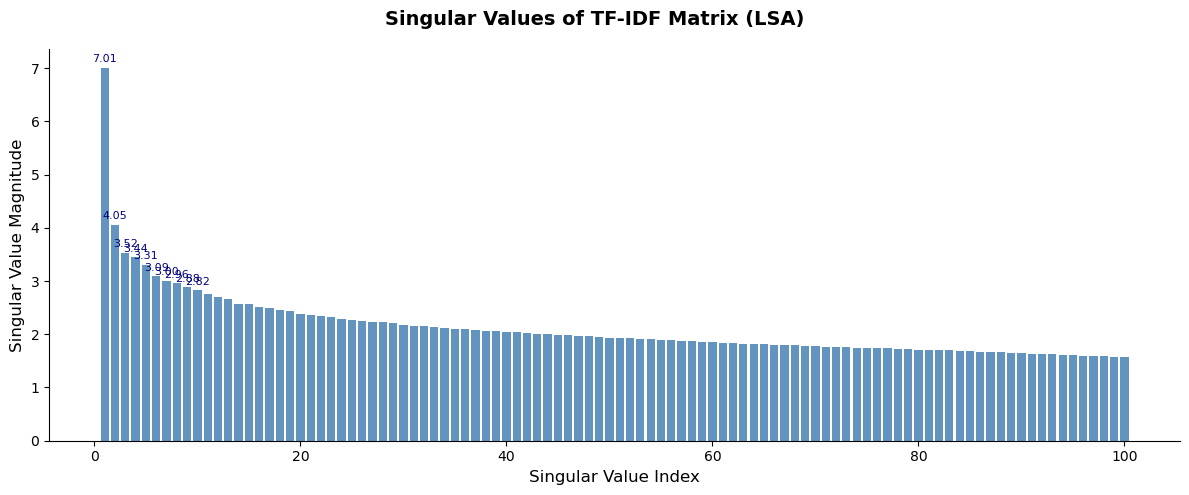


--- Singular Value Insights ---
  Largest SV  : 7.0090
  Smallest SV : 1.5758
  Ratio (σ1/σk): 4.45x
  Top-5 SVs   : [7.009  4.0523 3.5248 3.4448 3.3053]
  Interpretation: A steep drop from σ1 suggests a few dominant latent topics;
  a gradual decay indicates distributed topic structure across reviews.


In [8]:
# ── Graph 1: Raw Singular Values ────────────────────────────────────────────
fig1, ax1 = plot_singular_values(singular_values)
plt.show()

print("\n--- Singular Value Insights ---")
print(f"  Largest SV  : {singular_values[0]:.4f}")
print(f"  Smallest SV : {singular_values[-1]:.4f}")
print(f"  Ratio (σ1/σk): {singular_values[0]/singular_values[-1]:.2f}x")
print(f"  Top-5 SVs   : {np.round(singular_values[:5], 4)}")
print("  Interpretation: A steep drop from σ1 suggests a few dominant latent topics;")
print("  a gradual decay indicates distributed topic structure across reviews.")

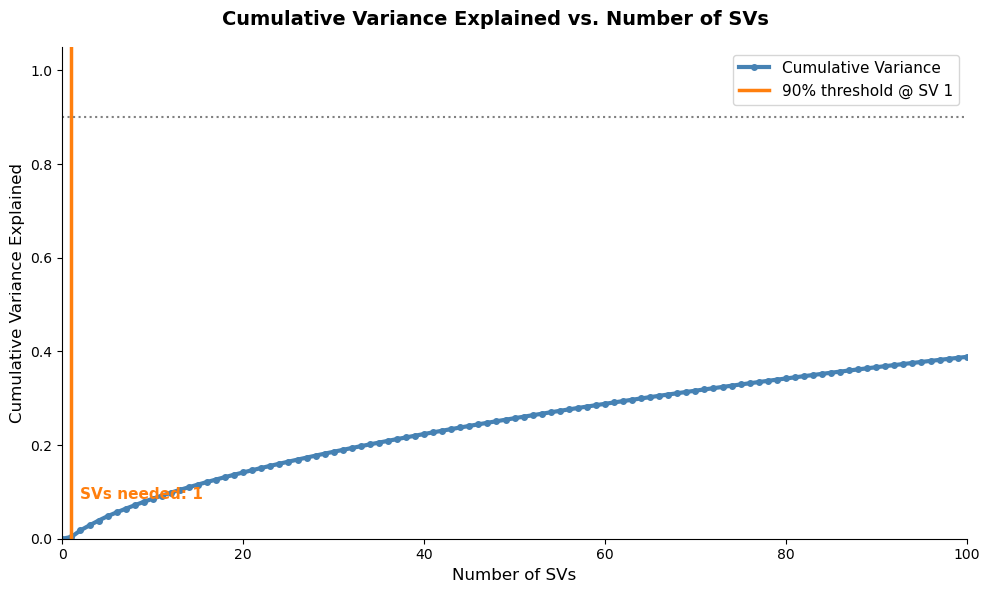


SVs needed to explain 90% variance: 1
Variance explained by first SV     : 0.39%
Variance explained by top-1 SVs : 0.39%


In [9]:
# ── Graph 2: Cumulative Variance Explained (variance, not energy) ────────────
fig2, ax2, thresh = plot_variance_cumulative(variance_explained, tol=0.90)
plt.show()

print(f"\nSVs needed to explain 90% variance: {thresh}")
print(f"Variance explained by first SV     : {variance_explained[0]*100:.2f}%")
print(f"Variance explained by top-{thresh} SVs : {variance_explained[:thresh].sum()*100:.2f}%")

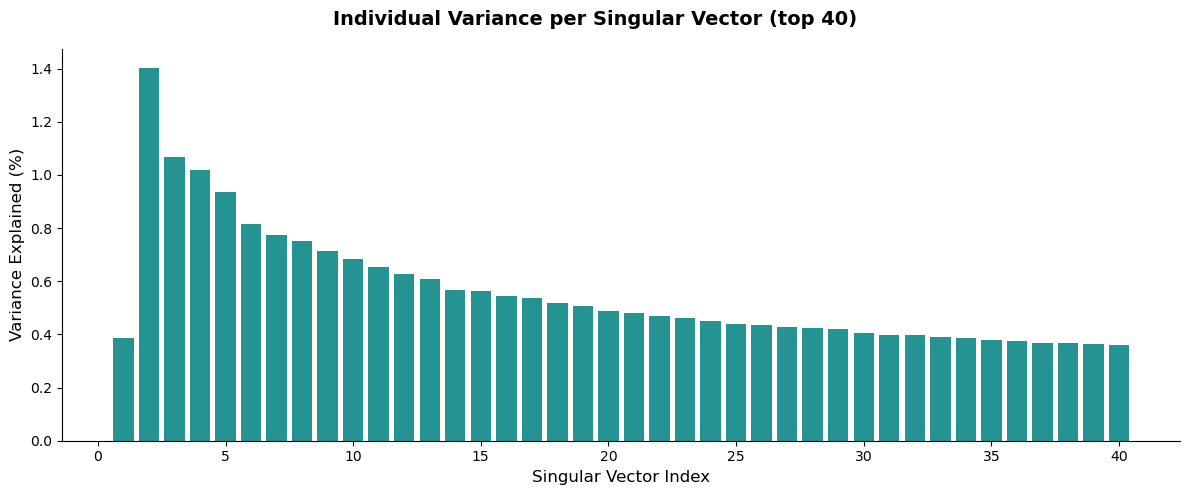

In [10]:
# ── Graph 3: Per-SV Variance ─────────────────────────────────────────────────
fig3, ax3 = plot_variance_per_sv(variance_explained, n_show=40)
plt.show()

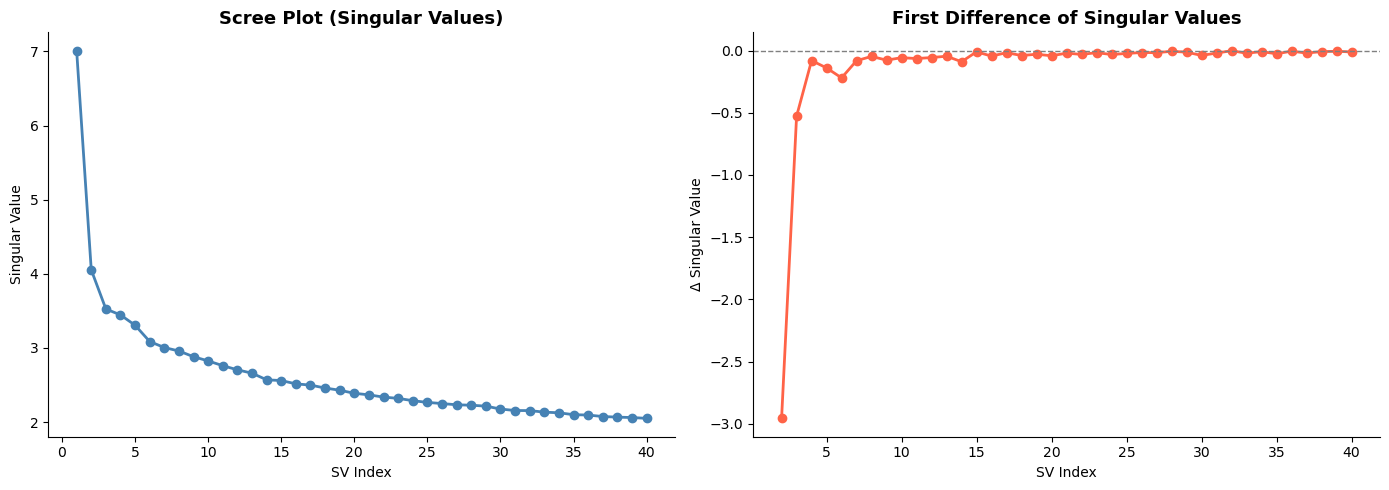


Scree Insight:
  The elbow in the first-difference plot marks where marginal information
  gain from additional SVs diminishes rapidly — a natural cut-point for
  dimensionality reduction beyond the 90%-variance threshold.


In [11]:
# ── Graph 4: Scree Plot ───────────────────────────────────────────────────────
fig4, axes4 = plot_scree(singular_values, n_show=40)
plt.show()

print("\nScree Insight:")
print("  The elbow in the first-difference plot marks where marginal information")
print("  gain from additional SVs diminishes rapidly — a natural cut-point for")
print("  dimensionality reduction beyond the 90%-variance threshold.")

In [12]:
# Truncate LSA to 90%-variance threshold
thresh = max(thresh, 2)
truncated_lsa_train = lsa_train[:, :thresh]
truncated_lsa_test = lsa_test[:, :thresh]
print(f"Truncated LSA Train shape: {truncated_lsa_train.shape}")
print(f"Truncated LSA Test shape: {truncated_lsa_test.shape}")
print(f"Using {thresh} latent semantic dimensions for clustering.")

Truncated LSA Train shape: (1210, 2)
Truncated LSA Test shape: (303, 2)
Using 2 latent semantic dimensions for clustering.


## Clustering: K-Means + DBSCAN + Hierarchical Agglomerative

Three complementary clustering paradigms are applied to the LSA-reduced space:

| Method | Paradigm | Key strength |
|---|---|---|
| **K-Means** | Partition-based | Fast; identifies globular centroids |
| **DBSCAN** | Density-based | Detects arbitrary shapes; labels noise as -1 |
| **Agglomerative** | Hierarchical (representative) | Reveals nested cluster structure via dendrogram |

In [14]:
# Clustering semantic features
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_km = kmeans.fit_predict(truncated_lsa_train)
df_train['cluster_kmeans'] = clusters_km
df_train.head()

print("K-Means cluster distribution:")
print(pd.Series(clusters_km).value_counts().sort_index())

K-Means cluster distribution:
0    238
1    291
2    169
3    277
4    235
Name: count, dtype: int64


### DBSCAN — Density-Based Spatial Clustering

DBSCAN groups points that are tightly packed together and marks low-density points as noise
(label = -1). Unlike K-Means it does **not** require specifying k in advance.
The `eps` (neighbourhood radius) is estimated from the k-NN distance plot.

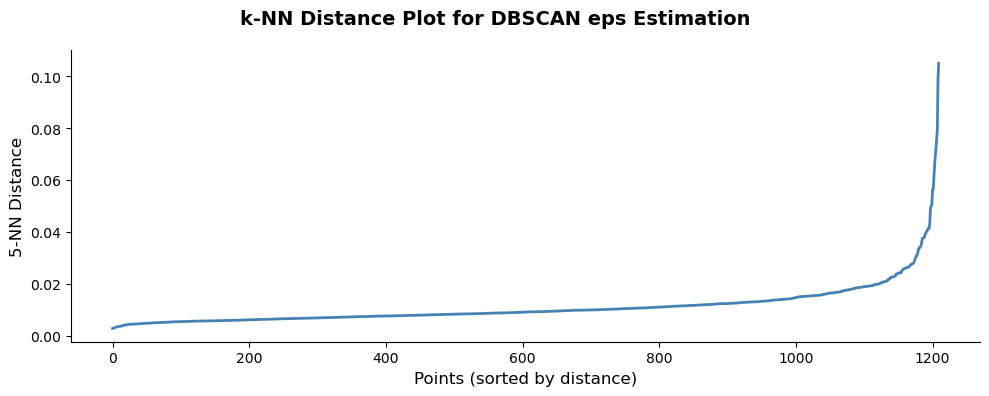

Estimated eps (5th percentile of 5-NN distances): 0.0242


In [15]:
# ── DBSCAN: Estimate eps via k-NN distance plot ───────────────────────────────

k = 5
nbrs = NearestNeighbors(n_neighbors=k, algorithm='ball_tree').fit(truncated_lsa_train)
distances, _ = nbrs.kneighbors(truncated_lsa_train)
knn_dists = np.sort(distances[:, k-1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(knn_dists, lw=2, color='steelblue')
ax.set_xlabel('Points (sorted by distance)', fontsize=12)
ax.set_ylabel(f'{k}-NN Distance', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('k-NN Distance Plot for DBSCAN eps Estimation', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# EPS
kneel = KneeLocator(range(len(knn_dists)), knn_dists, curve='convex', direction='increasing')
eps_est = knn_dists[kneel.knee]
print(f"Estimated eps (5th percentile of {k}-NN distances): {eps_est:.4f}")

In [16]:
# ── Run DBSCAN ───────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=eps_est, min_samples=5, metric='euclidean', n_jobs=-1)
clusters_db = dbscan.fit_predict(truncated_lsa_train)
df_train['cluster_dbscan'] = clusters_db

n_clusters_db = len(set(clusters_db)) - (1 if -1 in clusters_db else 0)
n_noise_db    = (clusters_db == -1).sum()

print(f"DBSCAN found {n_clusters_db} cluster(s) + {n_noise_db} noise points")
print("Cluster distribution (−1 = noise):")
print(pd.Series(clusters_db).value_counts().sort_index())

DBSCAN found 1 cluster(s) + 34 noise points
Cluster distribution (−1 = noise):
-1      34
 0    1176
Name: count, dtype: int64


### Hierarchical Agglomerative Clustering (HAC)

HAC merges the two closest clusters at each step using **Ward linkage** (minimises
within-cluster variance). The resulting dendrogram gives a multi-resolution view of the
cluster structure — useful for choosing the number of clusters without pre-specifying k.

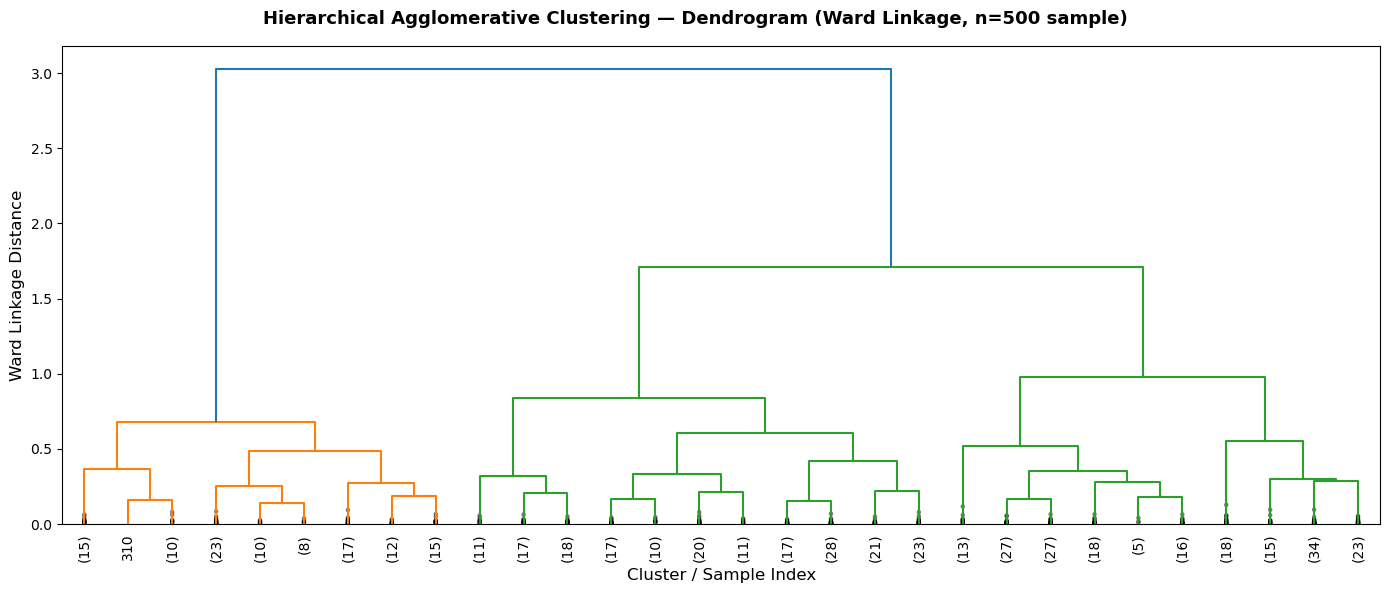

HAC cluster distribution (sample, 5 clusters):
1    111
2     46
3    147
4    106
5     90
Name: count, dtype: int64


In [17]:
# ── Hierarchical Agglomerative Clustering ────────────────────────────────────
# Subsample for dendrogram readability (linkage on full dataset is expensive)
np.random.seed(42)
sample_idx  = np.random.choice(len(truncated_lsa_train), size=min(500, len(truncated_lsa_train)), replace=False)
sample_lsa  = truncated_lsa_train[sample_idx]

Z = linkage(sample_lsa, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10, show_contracted=True)
ax.set_xlabel('Cluster / Sample Index', fontsize=12)
ax.set_ylabel('Ward Linkage Distance', fontsize=12)
fig.suptitle('Hierarchical Agglomerative Clustering — Dendrogram (Ward Linkage, n=500 sample)',
             fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

# Cut dendrogram at 5 clusters to match K-Means for comparability
hac_labels_sample = fcluster(Z, t=5, criterion='maxclust')
print(f"HAC cluster distribution (sample, 5 clusters):")
print(pd.Series(hac_labels_sample).value_counts().sort_index())

In [18]:
# Apply HAC to full dataset via linkage on full matrix
MAX_HAC_ROWS = 10_000
if len(truncated_lsa_train) > MAX_HAC_ROWS:
    print(f"Dataset too large for full HAC linkage ({len(truncated_lsa_train)} rows); skipping full HAC clustering.")
else:
    Z_full = linkage(truncated_lsa_train, method='ward', metric='euclidean')
    clusters_hac = fcluster(Z_full, t=5, criterion='maxclust') - 1  # 0-indexed

df_train['cluster_hac'] = clusters_hac

print("HAC full-dataset cluster distribution:")
print(pd.Series(clusters_hac).value_counts().sort_index())

HAC full-dataset cluster distribution:
0    127
1    230
2    408
3    241
4    204
Name: count, dtype: int64


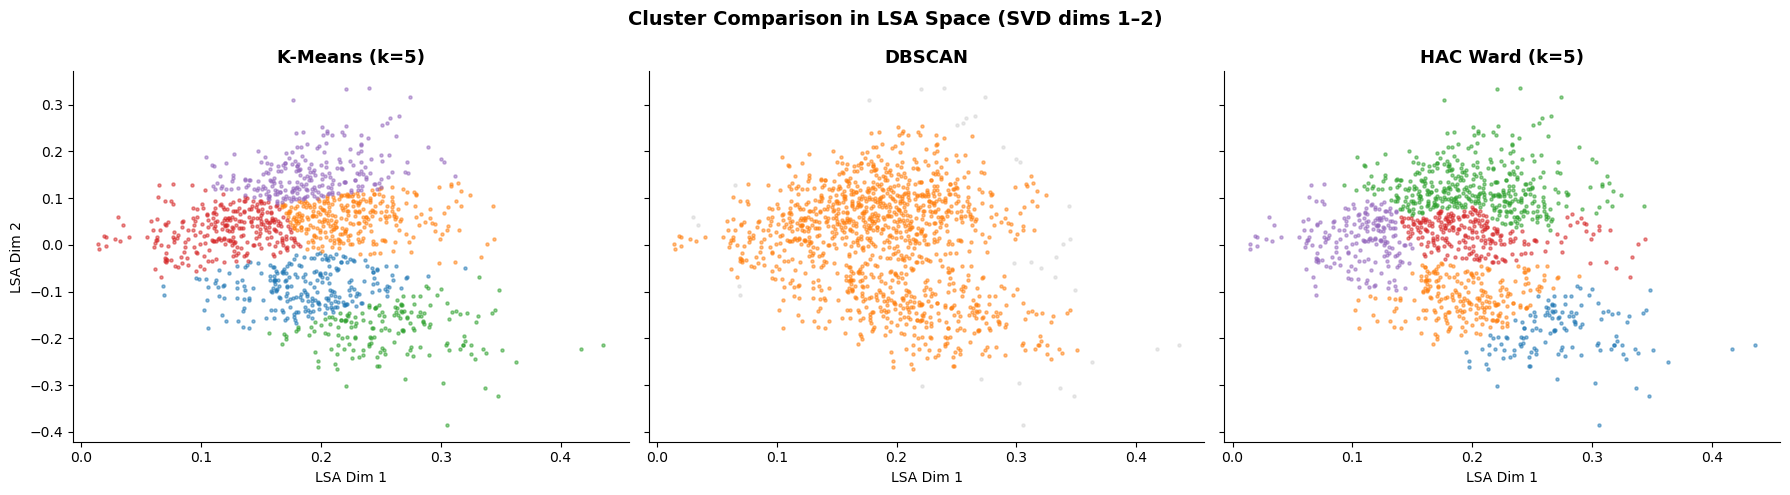

Clustering Observations:
  K-Means:       Produces balanced, globular clusters; sensitive to initialisation.
  DBSCAN:        Identifies dense review neighbourhoods; noise points may be outlier reviews.
  HAC (Ward):    Reveals hierarchical topic structure; most stable for nested themes.


In [19]:
# ── 2-D projection (SVD dim 0 vs dim 1) coloured by each method ───────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
palette = sns.color_palette('tab10', 10)

for ax, (labels, title) in zip(axes, [
    (clusters_km,  'K-Means (k=5)'),
    (clusters_db,  'DBSCAN'),
    (clusters_hac, 'HAC Ward (k=5)'),
]):
    unique = sorted(set(labels))
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        color = 'lightgray' if lbl == -1 else palette[i % 10]
        lname = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(truncated_lsa_train[mask, 0], truncated_lsa_train[mask, 1],
                   color=color, s=5, alpha=0.5, label=lname)
    ax.set_title(title, fontsize=13, weight='bold')
    ax.set_xlabel('LSA Dim 1')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('LSA Dim 2')
plt.suptitle('Cluster Comparison in LSA Space (SVD dims 1–2)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("Clustering Observations:")
print("  K-Means:       Produces balanced, globular clusters; sensitive to initialisation.")
print("  DBSCAN:        Identifies dense review neighbourhoods; noise points may be outlier reviews.")
print("  HAC (Ward):    Reveals hierarchical topic structure; most stable for nested themes.")

## Final Dataset: Fully Numerical, ML-Ready

The final feature table is assembled from:
- **LSA features** (truncated SVD dimensions) — semantic representation of review text
- **Encoded structured features** — rating, date parts, location frequency, text lengths
- **Cluster labels** — from K-Means, DBSCAN, and HAC
- **Target** — `is_helpful` (binary)

`helpful_votes` is **excluded as a feature** (data leakage guard) but remains in `df` for auditing.

In [20]:
# Helper Function
def build_ml_dataset(base_df, lsa_matrix, cluster_labels):
    """
    Safely constructs the ML-ready dataframe by combining LSA features,
    structured numerical features, cluster labels, and the target variable.
    """
    # 1. Build LSA DataFrame
    # Ensures the index matches the base dataframe (crucial after train_test_split!)
    n_components = lsa_matrix.shape[1]
    lsa_cols = [f'lsa_{i}' for i in range(n_components)]
    df_lsa = pd.DataFrame(lsa_matrix, columns=lsa_cols, index=base_df.index)
    
    # 2. Extract Structured Features
    # Note: 'helpful_votes' is strictly excluded here to prevent leakage
    structured_features = [
        'rating', 'month', 'review_age_days',
        'location_freq', 'title_len',
        'word_count', 'avg_word_len',
        'sentiment', 'sentiment_extremity'
    ]
    df_structured = base_df[structured_features].copy()
    
    # Add the cluster labels
    df_structured['cluster_kmeans'] = cluster_labels
    
    # Clean up any infinities caused by dividing by zero (e.g., empty reviews)
    df_structured.replace([np.inf, -np.inf], 0, inplace=True)
    
    # 3. Extract Target Variable
    df_target = base_df[['is_helpful']].copy()
    
    # 4. Concatenate horizontally
    df_final = pd.concat([df_lsa, df_structured, df_target], axis=1)
    
    # 5. Final safety net for any lingering NaNs
    df_final = df_final.fillna(0)
    
    return df_final

In [21]:
df_train_final = build_ml_dataset(df_train, truncated_lsa_train, train_clusters)
df_test_final  = build_ml_dataset(df_test, truncated_lsa_test, test_clusters)

NameError: name 'train_clusters' is not defined

In [ ]:
# ── Build final ML-ready feature DataFrame ───────────────────────────────────

# LSA columns
lsa_cols = [f'lsa_{i}' for i in range(truncated_lsa_train.shape[1])]
df_lsa_ = pd.DataFrame(truncated_lsa_train, columns=lsa_cols, index=df.index)

# Structured numerical features (NO helpful_votes — data leakage)
structured_features = ['rating', 'month', 'review_age_days',
                       'location_freq', 'title_len',
                       'word_count', 'avg_word_len',
                       'sentiment', 'sentiment_extremity']

df_structured = df[structured_features].copy()

# Target
df_target = df[['is_helpful']].copy()

# Concatenate everything
df_final = pd.concat([df_lsa, df_structured, df_target], axis=1)

print(f"Final dataset shape: {df_final.shape}")
print(f"\nAll dtypes numerical? {all(df_final.dtypes.apply(lambda x: np.issubdtype(x, np.number)))}")
print(f"\nColumn list ({len(df_final.columns)} columns):")
print(list(df_final.columns))
print("\nSample:")
df_final.head()

Final dataset shape: (1519, 12)

All dtypes numerical? True

Column list (12 columns):
['lsa_0', 'lsa_1', 'rating', 'month', 'review_age_days', 'location_freq', 'title_len', 'word_count', 'avg_word_len', 'sentiment', 'sentiment_extremity', 'is_helpful']

Sample:


,lsa_0,lsa_1,rating,month,review_age_days,location_freq,title_len,word_count,avg_word_len,sentiment,sentiment_extremity,is_helpful
0,0.261233,-0.089675,5,3,46,1190,31,61,9.131148,0.9876,0.9876,1
1,0.213880,0.028070,5,4,21,1190,23,43,11.511628,0.9547,0.9547,1
2,0.217613,-0.069014,5,4,22,1190,56,135,10.140741,0.9857,0.9857,1
3,0.279814,-0.098214,5,3,46,1190,31,82,11.402439,0.9953,0.9953,1
4,0.176138,-0.033742,5,4,7,1190,51,20,6.600000,0.9705,0.9705,0


In [ ]:
# ── Sanity Checks ───────────────────────────────────────────────────────────

# Catch categorical columns
cat_cols = df_final.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Remaining categorical columns: {cat_cols if cat_cols else 'None — all numerical ✓'}")

# Catch missing values
print("\nMissing values per column (top offenders):")
missing = df_final.isnull().sum()
print(missing[missing > 0] if missing.any() else "  None ✓")

# Catch zero variance columns
zero_var = [col for col in df_final.columns if df_final[col].nunique() <= 1]
print("\nZero variance columns:", zero_var if zero_var else "None ✓")

# Class Balance Check
print("\nTarget Distribution:")
print(df_final['is_helpful'].value_counts(normalize=True).round(3))

# Fill any edge-case NaNs and infs
df_final = df.fillna(0)
df_final.replace([np.inf, -np.inf], 0, inplace=True)

# Check for remaining NaN or inf values
has_nan = df_final.isna().any().any()
has_inf = np.isinf(df_final.select_dtypes(include=[np.number])).any().any()

if has_nan or has_inf:
    print("Warning: Data still contains NaN or inf values!")
    print(f"NaN present: {has_nan}, Inf present: {has_inf}")
else:
    print("No NaN or inf values detected.")

print("\nFinal shape after NaN and inf fill:", df.shape, '\n')

Remaining categorical columns: None — all numerical ✓

Missing values per column (top offenders):
  None ✓

Zero variance columns: None ✓

Target Distribution:
is_helpful
1    0.608
0    0.392
Name: proportion, dtype: float64

Final shape after NaN and inf fill: (1519, 12) 



In [ ]:
# ── Export final dataset ─────────────────────────────────────────────────────
# Full df (with helpful_votes and text columns) for reference
df.to_csv("data/amazon_bestsellers_reviews_cleaned_clustered.csv", index=False)

# ML-ready numerical dataset (helpful_votes excluded)
df_final.to_csv("data/amazon_bestsellers_reviews_ml_ready.csv", index=False)

print("Exported:")
print("  • data/amazon_bestsellers_reviews_cleaned_clustered.csv  — full reference dataset")
print("  • data/amazon_bestsellers_reviews_ml_ready.csv           — ML-ready (all numerical, no leakage)")

Exported:
  • data/amazon_bestsellers_reviews_cleaned_clustered.csv  — full reference dataset
  • data/amazon_bestsellers_reviews_ml_ready.csv           — ML-ready (all numerical, no leakage)
